In [1]:
import logging
import warnings

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GroupKFold

from un_general_debate_analysis.external import load_all
from un_general_debate_analysis.preprocessing import OUT_DIR

warnings.filterwarnings("ignore", category=FutureWarning)
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)  # no "semibold" font in some setups
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

# one palette for the whole notebook (same as the other SDG 9 notebooks)
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = SERIES
INK, INK_SOFT, GRID = "#0b0b0b", "#52514e", "#dddcd7"
SEQ_BLUE = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
DIVERGING = LinearSegmentedColormap.from_list("bark_byte", [ORANGE, "#ffffff", BLUE])

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "figure.facecolor": "white",
    "axes.facecolor": "white", "axes.edgecolor": GRID, "axes.labelcolor": INK_SOFT,
    "axes.titlesize": 12, "axes.titleweight": "semibold", "axes.titlecolor": INK,
    "axes.titlelocation": "left", "axes.titlepad": 10, "axes.labelsize": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "grid.alpha": 0.9,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": False, "legend.fontsize": 9, "lines.linewidth": 2.0, "font.size": 10,
})


def finish(ax, title=None, subtitle=None, xlabel=None, ylabel=None, legend=False, grid="y"):
    """Title, optional subtitle, axis labels and a recessive grid, applied the same way everywhere."""
    if title:
        ax.set_title(title, pad=16 if subtitle else 10)
    if subtitle:
        ax.text(0, 1.01, subtitle, transform=ax.transAxes, fontsize=8.5, color=INK_SOFT, va="bottom")
    ax.set_xlabel(xlabel or "")
    ax.set_ylabel(ylabel or "")
    ax.set_axisbelow(True)
    ax.grid(False)
    if grid:
        ax.grid(True, axis=grid)
    if legend and ax.get_legend_handles_labels()[0]:
        ax.legend(loc="best")
    return ax


def zscore(s):
    return (s - s.mean()) / s.std()


def mean_ci(g, col):
    """Mean and 95% half-width of ``col`` within each group of a groupby."""
    a = g[col].agg(["mean", "std", "count"])
    a["ci"] = 1.96 * a["std"] / np.sqrt(a["count"])
    return a

## 1. Data and measures

In [2]:
features = pd.read_csv(OUT_DIR / "speeches_features.csv")
external = load_all(verbose=False) # World Bank + WHR + EGDI, keyed on (country_code, year)

DI, IA = "digital_infrastructure", "internet_and_access" # use it for shorter labels
speech = features[["country_code", "country", "year", "region_name", "n_sentences"]].copy()

n_di, n_ia = features[f"{DI}_sentences"], features[f"{IA}_sentences"]
speech["dig_n"] = n_di + n_ia # digital sentences (pooled)
speech["mention"] = (speech["dig_n"] > 0).astype(int) # said anything digital? use it a flag
speech["salience"] = speech["dig_n"] / speech["n_sentences"] # topic share
said = speech["dig_n"].where(speech["dig_n"] > 0) # NaN when nothing was said
speech["sentiment"] = (n_di * features[f"{DI}_sentiment"] + n_ia * features[f"{IA}_sentiment"]) / said # avg sentiment
speech["promise"] = (features[f"{DI}_frame_promise_sentences"] + features[f"{IA}_frame_promise_sentences"]) / said

# Merge all data together
panel = speech.merge(external, on=["country_code", "year"], how="left")


# as LEAD function, get the metrics k years in the future 
def lead(col, k, name):
    s = external[["country_code", "year", col]].copy()
    s["year"] -= k
    return s.rename(columns={col: name})


# a speech is delivered in year t so t -> t+1 is the first full year after it.
# LEAD for internet users and mobile
for col, short in [("internet_users_pct", "internet"), ("mobile_per_100", "mobile")]:
    panel = panel.merge(lead(col, 1, f"{short}_t1"), on=["country_code", "year"], how="left")
    panel[f"{short}_gain_next"] = panel[f"{short}_t1"] - panel[col] # percentage points / subs per 100

panel["log_gdp"] = np.log(panel["gdp_per_capita_ppp"])
modern = panel[panel["year"].between(2005, 2024)].copy() # 2025 has no connectivity data yet

print(f"{len(modern):,} speeches, {modern['country_code'].nunique()} countries, {modern['year'].min()}-{modern['year'].max()}")
print(f"{modern['mention'].sum():,} speeches ({modern['mention'].mean():.0%}) contain at least one digital sentence; "
      f"median number of such sentences when they do: {modern.loc[modern['mention'] == 1, 'dig_n'].median():.0f}")
modern[["mention", "salience", "sentiment", "promise", "internet_users_pct", "mobile_per_100",
        "internet_gain_next", "perceived_corruption"]].describe().T[["count", "mean", "std", "min", "50%", "max"]]

3,857 speeches, 197 countries, 2005-2024
1,000 speeches (26%) contain at least one digital sentence; median number of such sentences when they do: 1


,count,mean,std,min,50%,max
mention,"3,857.000",0.259,0.438,0.000,0.000,1.000
salience,"3,857.000",0.005,0.012,0.000,0.000,0.159
sentiment,"1,000.000",0.281,0.453,-0.988,0.362,0.976
promise,"1,000.000",0.206,0.361,0.000,0.000,1.000
internet_users_pct,"3,661.000",45.958,31.710,0.065,44.875,100.000
mobile_per_100,"3,707.000",93.352,43.853,0.000,100.333,574.152
internet_gain_next,"3,457.000",2.722,3.284,-20.927,2.000,40.444
perceived_corruption,"2,169.000",0.746,0.183,0.035,0.799,0.983


**Most speeches say nothing digital, and those that do say very little.** About one speech in four (26%) contains a digital sentence and the median is a single sentence, so a speech's "sentiment" is usually the VADER score of *one* sentence. That is noisy, and it shapes the design: sentiment only exists when a country spoke, so the plots below either use the speeches that say something or use measures defined for every speech (mention, salience).

## 2. Q1 - Exploratory: does the tone of digital talk track connectivity?

### 2.1 Bark and byte over time

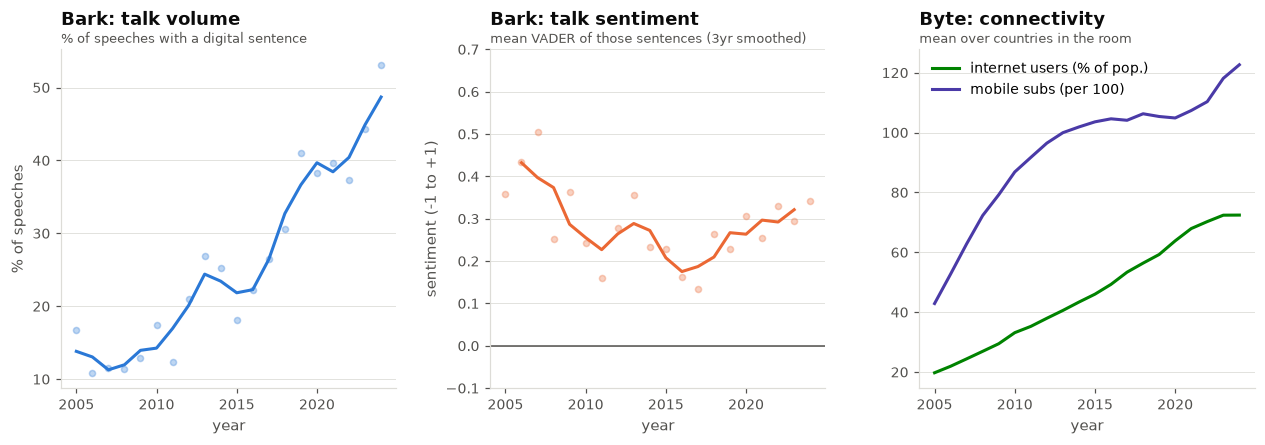

2005-09 -> 2020-24:
talk      13% -> 43% of speeches
sentiment 0.38 -> 0.31
internet  25% -> 69%
mobile    62 -> 113 per 100


In [81]:
# calculate yearly
yr = (modern.groupby("year").agg(talk=("mention", "mean"), 
                                sentiment=("sentiment", "mean"),
                                internet=("internet_users_pct", "mean"), 
                                mobile=("mobile_per_100", "mean"))
                            .query("year >= 2000 and year <= 2024")) # our period of interest, internet is a thing
# take rolling for smoothness
yr["talk_s"] = yr["talk"].rolling(3, center=True, min_periods=2).mean()
yr["sent_s"] = yr["sentiment"].rolling(3, center=True, min_periods=3).mean()

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True, gridspec_kw={"wspace": 0.28})

ax = axes[0]
ax.plot(yr.index, 100 * yr["talk"], "o", color=BLUE, alpha=0.3, ms=4)
ax.plot(yr.index, 100 * yr["talk_s"], color=BLUE)
finish(ax, "Bark: talk volume", "% of speeches with a digital sentence", ylabel="% of speeches")

ax = axes[1]
ax.axhline(0, color=INK_SOFT, lw=1)
ax.plot(yr.index, yr["sentiment"], "o", color=ORANGE, alpha=0.3, ms=4)
ax.plot(yr.index, yr["sent_s"], color=ORANGE)
ax.set_ylim(-0.1, 0.7)
finish(ax, "Bark: talk sentiment", "mean VADER of those sentences (3yr smoothed)", ylabel="sentiment (-1 to +1)")

ax = axes[2]
ax.plot(yr.index, yr["internet"], color=GREEN, label="internet users (% of pop.)")
ax.plot(yr.index, yr["mobile"], color=VIOLET, label="mobile subs (per 100)")
finish(ax, "Byte: connectivity", "mean over countries in the room", legend=True)

for ax in axes:
    ax.set_xlabel("year")
plt.show()


era_gap = yr.mean() - yr.mean()
print(f"2005-09 -> 2020-24:\n"
      f"talk      {100*yr.loc[2005:2009, 'talk'].mean():.0f}% -> {100*yr.loc[2020:2024,'talk'].mean():.0f}% of speeches\n"
      f"sentiment {yr.loc[2005:2009, 'sentiment'].mean():.2f} -> {yr.loc[2020:2024, 'sentiment'].mean():.2f}\n"
      f"internet  {yr.loc[2005:2009, 'internet'].mean():.0f}% -> {yr.loc[2020:2024, 'internet'].mean():.0f}%\n"
      f"mobile    {yr.loc[2005:2009, 'mobile'].mean():.0f} -> {yr.loc[2020:2024, 'mobile'].mean():.0f} per 100")

**The volume of talk and the connectivity of the world rise together; the tone does not move.** Between 2005-04 and 2020-24 the share of speeches with a digital sentence goes from 13% to 43%, internet use in the countries in the room from 25% to 69% of the population and mobile subscriptions from 62 to 113 per 100 people. Average sentiment barely changes (0.38 to 0.31) and shows no trend; the year-to-year wobble is the noise of a few hundred one-sentence scores. Two shared upward lines are a coincidence of timelines rather than evidence of a link, so the next plots compare countries *within* the same period.

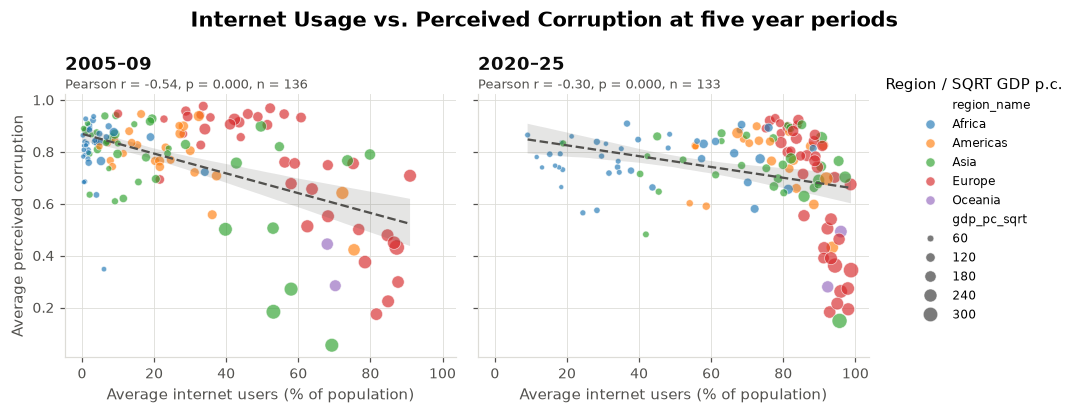

In [83]:
periods = ["2005–09", "2020–25"]

data = (modern.query("(year >= 2005 and year <= 2009) or (year >= 2020 and year <= 2025)")
    [["country_code", "region_name", "year", "internet_users_pct", "perceived_corruption", "whr_log_gdp_pc"]]
    .dropna(subset=["internet_users_pct", "perceived_corruption"]).copy())

data["gdp_pc"] = np.exp(data["whr_log_gdp_pc"])
data["gdp_pc_sqrt"] = np.sqrt(np.exp(data["whr_log_gdp_pc"]))

data["period"] = data["year"].apply(lambda y: periods[0] if y <= 2009 else periods[1])

period_data = (
    data.groupby(["period", "country_code", "region_name"], observed=True)
    [["internet_users_pct", "perceived_corruption", "gdp_pc_sqrt"]]
    .mean()
    .reset_index()
)

hue_order = sorted(period_data["region_name"].unique())
palette = dict(zip(hue_order, sns.color_palette(n_colors=len(hue_order))))

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

for ax, period in zip(axes.flat, periods):
    subset = period_data[period_data["period"].eq(period)]

    sns.scatterplot(data=subset, x="internet_users_pct", y="perceived_corruption",
                    hue="region_name", hue_order=hue_order, palette=palette,
                    size="gdp_pc_sqrt", sizes=(10, 100), alpha=0.65,
                    edgecolor="white", linewidth=0.5, ax=ax,
                    legend=(period == periods[0]),
    )

    subtitle = ""
    if len(subset) > 1:
        sns.regplot(data=subset, x="internet_users_pct", y="perceived_corruption",
                    scatter=False, color=INK_SOFT, line_kws={"linestyle": "--", "linewidth": 1.5},
                    ax=ax,
        )
        rho, p = stats.pearsonr(subset["internet_users_pct"], subset["perceived_corruption"])
        subtitle = f"Pearson r = {rho:+.2f}, p = {p:.3f}, n = {len(subset)}"

    finish(ax, f"{period}", subtitle, xlabel="Average internet users (% of population)",
        ylabel="Average perceived corruption" if ax in axes else "", grid="both",
    )

handles, labels = axes.flat[0].get_legend_handles_labels()
axes.flat[0].legend_.remove()
fig.suptitle("Internet Usage vs. Perceived Corruption at five year periods", fontsize=14, fontweight="bold", y=0.93)

fig.legend(handles, labels, loc="center left",
    bbox_to_anchor=(0.8, 0.5), fontsize=8, title="Region / SQRT GDP p.c.", frameon=False,
)

plt.tight_layout(rect=[0, 0, 0.81, 0.95])
plt.savefig("corruption_it_usage", bbox_inches="tight")
plt.show()

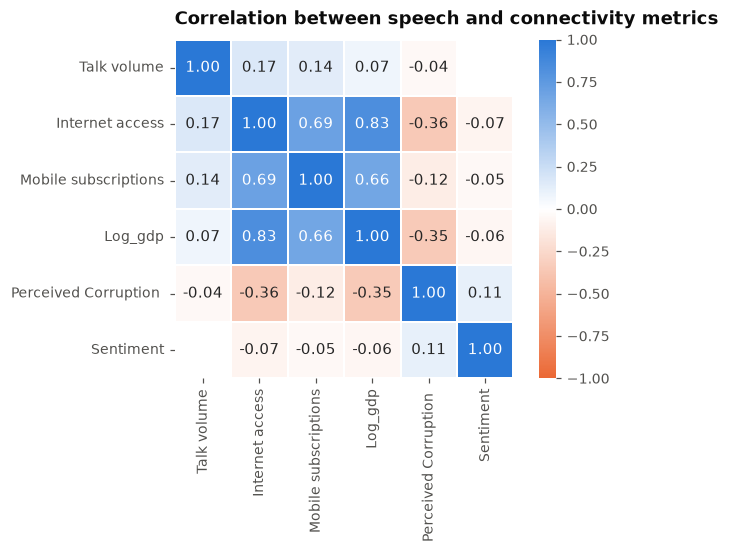

In [102]:
metrics = (modern
    .query('year >= 2005 and year <= 2025')
    .groupby(['year', 'country_code'])
    .agg(
        talk=("mention", "mean"),
        sentiment=("sentiment", "mean"),
        internet=("internet_users_pct", "mean"), 
        mobile=("mobile_per_100", "mean"),
        corruption=("perceived_corruption", "mean"),
        gdp=("whr_log_gdp_pc","mean"))
)
metrics = metrics.rename(columns={
    "talk": "Talk volume",
    "sentiment": "Sentiment",
    "internet": "Internet access",
    "mobile": "Mobile subscriptions",
    "corruption" : "Perceived Corruption ",
    "gdp": "Log_gdp"
})

# Pearson correlations
corr = metrics.corr(method="pearson")
corr = corr.sort_values('Talk volume', ascending=False)
corr = corr[corr.index]

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap=DIVERGING, vmin=-1, vmax=1,
    center=0, square=True, linewidths=1, linecolor="white", ax=ax,)

finish(ax, "Correlation between speech and connectivity metrics", grid=None)
plt.show()

### Q1 in short

* **Volume moves with connectivity; tone does not.** Digital talk becomes far more common as the world gets connected (19% to 43% of speeches), but average sentiment stays flat at about +0.3.
* **Across countries, tone and connectivity are unrelated** (rho about -0.1, not significant), for both internet use and mobile subscriptions. If anything, better-connected countries sound slightly *cooler*.
* **So the exploratory answer to "all bark, no byte?" is that bark and byte are simply uncorrelated in tone.** Positive digital rhetoric is not a marker of connected countries.

## 3. Q2 - Predictive: does sentiment forecast next year's gain, and does corruption matter?

### 3.1 Design

* **Target:** `internet_gain_next`, the change in % of the population online from year `t` to `t+1` (percentage points).
* **Unit:** a speech (country-year), 2005-2023, restricted to speeches whose country has a corruption score, a GDP figure and a next-year internet value.
* **Speech features:** whether the country mentioned digital topics, the topic share, the sentiment and the promise framing. Sentiment and framing are set to 0 (neutral) when nothing was said, and the mention flag lets a model tell "silent" from "neutral".
* **Context features in every model:** internet level at `t`, its square, log GDP per capita and the year. Adoption follows an S-curve, so *where a country is on the curve* is the obvious predictor of its next gain, and the speeches have to add to *that*.
* **Two models:** a regularised linear model (Ridge) and a random forest, so the relationship can be linear or non-linear.
* **Validation:** repeated 5-fold cross-validation that **holds out whole countries**, so a model cannot look up a country's own history.

2,113 speeches from 150 countries, 2005-2023; 574 of them contain digital talk
mean next-year gain 2.76 pp (sd 3.39)


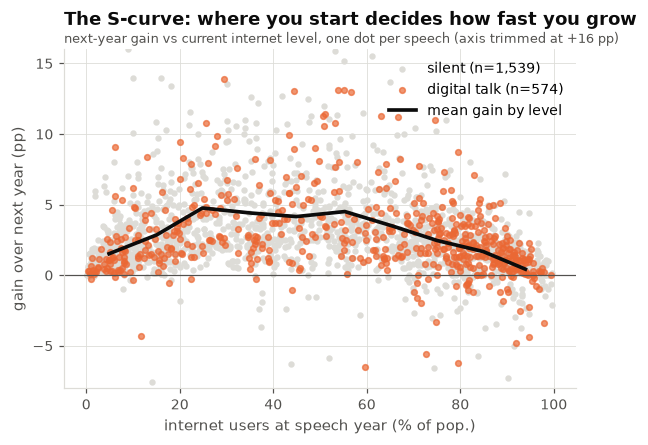

In [106]:
q2 = (panel[panel["year"].between(2005, 2023)]
      .dropna(subset=["internet_gain_next", "perceived_corruption", "internet_users_pct", "log_gdp"]).copy())


print(f"{len(q2):,} speeches from {q2['country_code'].nunique()} countries, {q2['year'].min()}-{q2['year'].max()}; "
      f"{q2['mention'].sum()} of them contain digital talk")
print(f"mean next-year gain {q2['internet_gain_next'].mean():.2f} pp (sd {q2['internet_gain_next'].std():.2f})")

fig, ax = plt.subplots(1, 1, figsize=(6, 4))

quiet, talk = q2[q2["mention"] == 0], q2[q2["mention"] == 1]
ax.scatter(quiet["internet_users_pct"], quiet["internet_gain_next"], s=10, color=GRID, label=f"silent (n={len(quiet):,})")
ax.scatter(talk["internet_users_pct"], talk["internet_gain_next"], s=14, color=ORANGE, alpha=0.7, label=f"digital talk (n={len(talk):,})")

bins = pd.cut(x=q2["internet_users_pct"], bins=np.arange(0, 101, 10), include_lowest=True)
curve = q2.groupby(bins, observed=True).agg(x=("internet_users_pct", "mean"), y=("internet_gain_next", "mean"))
ax.plot(curve["x"], curve["y"], color=INK, lw=2.4, label="mean gain by level")

ax.axhline(0, color=INK_SOFT, lw=0.8)
ax.set_ylim(-8, 16)
finish(ax, "The S-curve: where you start decides how fast you grow",
       "next-year gain vs current internet level, one dot per speech (axis trimmed at +16 pp)", xlabel="internet users at speech year (% of pop.)",
       ylabel="gain over next year (pp)", grid="both")
ax.legend(loc="upper right")

plt.show()

Two things to take from the pictures. **Next year's gain is mostly a function of where a country already is**: gains are largest (about 4-5 pp) between roughly 20% and 60% online and shrink towards saturation, to under 1 pp above 90% (so the context features will do a lot of work). And **digital talk is spread all along the curve** rather than concentrated at one end; it is a little more common in low-corruption countries (about 30% of speeches vs 24% in the high-corruption tercile), which is a first hint that corruption relates to the talk itself.

### 3.2 Feature sets and models

In [ ]:
CONTEXT = ["internet_users_pct", "internet_sq", "log_gdp"]
SENT = ["sentiment_f"]
TALK = ["mention", "salience", "promise_f"]
CORR = ["perceived_corruption"]


q2["internet_sq"] = q2["internet_users_pct"] ** 2 / 100
q2["sentiment_f"] = q2["sentiment"].fillna(0)
q2["promise_f"] = q2["promise"].fillna(0)

z = q2.copy()
for col in ["internet_users_pct", "internet_sq", "log_gdp", "salience", "sentiment_f", "promise_f", "perceived_corruption"]:
    z[col] = zscore(z[col])

FEATURE_SETS = {
    "A. context only": CONTEXT,
    "B. + sentiment": CONTEXT + SENT,
    "C. + all talk (topic share, framing)": CONTEXT + SENT + TALK,
    "D. + corruption": CONTEXT + SENT + TALK + CORR,
}

MODELS = {
    "Ridge (linear)": lambda: Ridge(alpha=10.0),
    "Random forest": lambda: RandomForestRegressor(n_estimators=250, min_samples_leaf=10, max_features=0.5, random_state=0, n_jobs=-1),
}
YEARS = np.array(sorted(z["year"].unique()))


def design(cols, model):
    X = z[cols].to_numpy(float)
    # If it is ridge, encode year as one-hot, else leave it as number which the decision tree can handle
    if model.startswith("Ridge"):
        return np.column_stack([X, (z["year"].to_numpy()[:, None] == YEARS[1:]).astype(float)])
    return np.column_stack([X, z["year"].to_numpy(float)])


def cv_scores(X, y, groups, model_fn, repeats=8, folds=5):
    r2, mae = [], []
    for seed in range(repeats):
        pred = np.empty(len(y))
        for tr, te in GroupKFold(folds, shuffle=True, random_state=seed).split(X, y, groups):
            pred[te] = model_fn().fit(X[tr], y[tr]).predict(X[te])
        r2.append(r2_score(y, pred))
        mae.append(mean_absolute_error(y, pred))
    return np.array(r2), np.array(mae)


y, groups = z["internet_gain_next"].to_numpy(float), z["country_code"].to_numpy()
rows = []
for model, model_fn in MODELS.items():
    for name, cols in FEATURE_SETS.items():
        r2, mae = cv_scores(design(cols, model), y, groups, model_fn)
        rows.append({"model": model, "features": name, "R2": r2.mean(), "R2 sd": r2.std(), "MAE (pp)": mae.mean()})
cv = pd.DataFrame(rows)
print(f"baseline MAE of always predicting the mean: {mean_absolute_error(y, np.full(len(y), y.mean())):.2f} pp\n")
print(cv.to_string(index=False))

In [28]:
X = design(CONTEXT, "Rigde")
tr, te  = GroupKFold(2, shuffle=True, random_state=1).split(X, y, groups)
model = Ridge(alpha=10.0)
pred = model.fit(X[tr[0]], y[tr[0]]).predict(X[te[0]])

In [35]:
pred_train = model.fit(X[tr[0]], y[tr[0]]).predict(X[tr[0]])

(-1.0, 10.0)

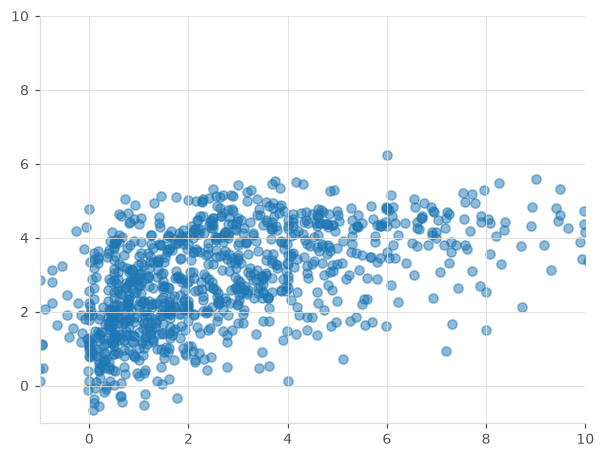

In [37]:
fig, ax = plt.subplots()
plt.scatter(y[tr[0]], pred_train, alpha=0.5)
ax.set_ylim(-1, 10)
ax.set_xlim(-1, 10)

(-1.0, 10.0)

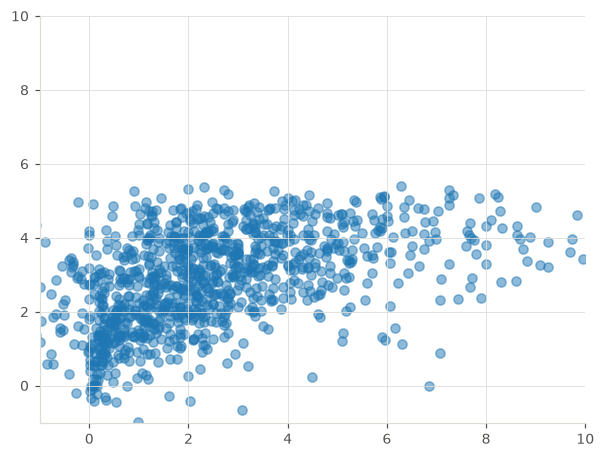

In [ ]:

fig, ax = plt.subplots()
plt.scatter(y[te[0]], pred, alpha=0.5);ax.set_ylim(-1, 10)
ax.set_xlim(-1, 10)

### NOTE EXPLAINING THE NEXT CELL
The table shows that talk features do not improve prediction on average. The next cell asks a narrower question: could sentiment matter *only* in some countries, namely those with high perceived corruption, where warm words might be less credible? It does this in three steps:

1. **Removes what the context already explains.** A linear regression of next-year gain on internet level, its square, log GDP and year dummies is fitted, and the leftover (the residual) is stored as `gain_resid`: the growth a country achieved *beyond* what its position on the S-curve predicts.
2. **Keeps only speeches with digital talk and splits them into corruption terciles** (low, middle, high), since sentiment only exists for those speeches.
3. **Plots sentiment against `gain_resid` in each tercile**, with a fitted line, its 95% confidence band and the Spearman correlation.

If warm digital talk were "bark without byte" in corrupt countries, the slope would be flat or negative in the high-corruption panel and positive in the low-corruption one.

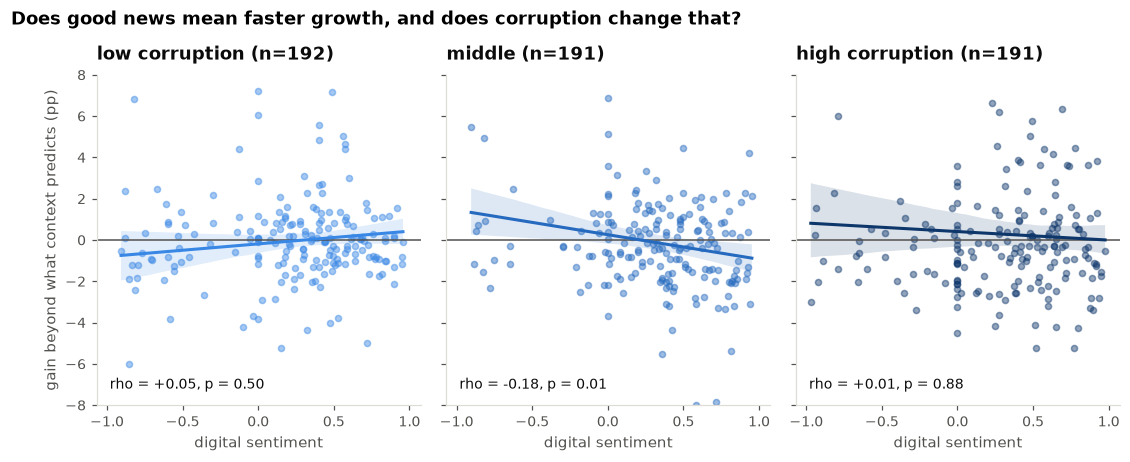

In [ ]:
# Moderation, visually: strip out what the context already explains, then ask how the leftover gain
# relates to sentiment within each corruption tercile.
Xc = np.column_stack([np.ones(len(z)), design(CONTEXT, "Ridge (linear)")])
q2["gain_resid"] = y - Xc @ np.linalg.lstsq(Xc, y, rcond=None)[0]

t = q2[q2["mention"] == 1].copy()
t["corr_tercile"] = pd.qcut(t["perceived_corruption"], 3, labels=["low corruption", "middle", "high corruption"])

fig, axes = plt.subplots(1, 3, figsize=(12, 3.9), sharex=True, sharey=True, gridspec_kw={"wspace": 0.08})
for ax, (name, g), color in zip(axes, t.groupby("corr_tercile", observed=True), [SEQ_BLUE[3], SEQ_BLUE[4], SEQ_BLUE[6]]):
    ax.axhline(0, color=INK_SOFT, lw=1)
    sns.regplot(data=g, x="sentiment", y="gain_resid", color=color, ci=95, ax=ax,
                scatter_kws={"s": 16, "alpha": 0.45}, line_kws={"lw": 2})
    r, p = stats.spearmanr(g["sentiment"], g["gain_resid"])
    ax.text(0.04, 0.05, f"rho = {r:+.2f}, p = {p:.2f}", transform=ax.transAxes, fontsize=9, color=INK)
    finish(ax, f"{name} (n={len(g)})", xlabel="digital sentiment", ylabel="gain beyond what context predicts (pp)" if name.startswith("low") else "",
           grid=None)
ax.set_ylim(-8, 8)
fig.suptitle("Does good news mean faster growth, and does corruption change that?", x=0.06, ha="left",
             fontsize=12, fontweight="semibold", y=1.03)
plt.show()

There is no sign that warmer talk goes with faster growth in any group: the slope is only distinguishable from zero in the *middle* tercile, and there it is negative (rho = -0.18, p = 0.01); it is about zero in the low (+0.05) and high (+0.01) terciles.

A true moderation effect by corruption should grow steadily from one end to the other. This one does not, and it appears in one of three subgroups, which is about what chance alone would give across several comparisons. Treat it as a hint at most.

### 3.3 Promises instead of tone

VADER only measures how positive the wording is, not whether a country commits to anything. "Digital technology is wonderful" and "we will connect every village by 2030" can score alike, but only the second is a promise that could show up as growth. The `promise` measure captures that: the share of a speech's digital sentences that are framed as a promise (0 = none, 1 = all).

The next cell repeats the previous moderation check with `promise` in place of sentiment. It reuses `gain_resid` (growth beyond what internet level, GDP and year predict) and the same corruption terciles, and adds a simple comparison of speeches with and without any promise. Most speeches score exactly 0 or 1 because they contain only one digital sentence, so the points are jittered slightly along the x-axis and the fitted lines should be read loosely.

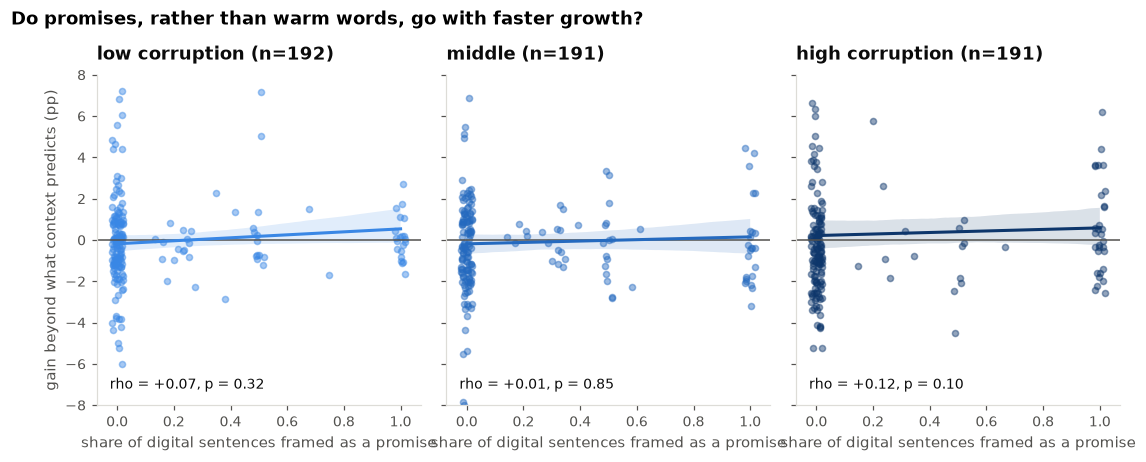

                              count   mean
corr_tercile    promised                  
low corruption  no promise      137 -0.170
                some promise     55  0.250
middle          no promise      131 -0.190
                some promise     60  0.040
high corruption no promise      143  0.050
                some promise     48  0.980


In [12]:
# Same moderation check, but with the promise framing instead of VADER sentiment.
# promise = share of the speech's digital sentences framed as a promise (0 = none, 1 = all);
# it reuses `gain_resid` and the corruption terciles built in the previous cell.
fig, axes = plt.subplots(1, 3, figsize=(12, 3.9), sharex=True, sharey=True, gridspec_kw={"wspace": 0.08})
for ax, (name, g), color in zip(axes, t.groupby("corr_tercile", observed=True), [SEQ_BLUE[3], SEQ_BLUE[4], SEQ_BLUE[6]]):
    ax.axhline(0, color=INK_SOFT, lw=1)
    sns.regplot(data=g, x="promise", y="gain_resid", color=color, ci=95, ax=ax, x_jitter=0.02,  # jitter: many speeches sit at exactly 0 or 1
                scatter_kws={"s": 16, "alpha": 0.45}, line_kws={"lw": 2})
    r, p = stats.spearmanr(g["promise"], g["gain_resid"])
    ax.text(0.04, 0.05, f"rho = {r:+.2f}, p = {p:.2f}", transform=ax.transAxes, fontsize=9, color=INK)
    finish(ax, f"{name} (n={len(g)})", xlabel="share of digital sentences framed as a promise",
           ylabel="gain beyond what context predicts (pp)" if name.startswith("low") else "", grid=None)
ax.set_ylim(-8, 8)
fig.suptitle("Do promises, rather than warm words, go with faster growth?", x=0.06, ha="left",
             fontsize=12, fontweight="semibold", y=1.03)
plt.show()

# the same idea without a slope: mean leftover gain for speeches with no promise vs at least one
t["promised"] = np.where(t["promise"] > 0, "some promise", "no promise")
print(t.groupby(["corr_tercile", "promised"], observed=True)["gain_resid"].agg(["count", "mean"]).round(2))

Promises tell the same story as tone: **no reliable link to growth, in any corruption group.** Among speeches with digital talk, the correlation between the promise share and the gain beyond what context predicts is small and not significant in the low (rho = +0.07, p = 0.32), middle (+0.01, p = 0.85) and high (+0.12, p = 0.10) terciles. All three point slightly upwards, which is the direction a "promises turn into byte" story would predict, but none is distinguishable from zero, and the size does not grow from the low to the high end.

The with/without comparison agrees. Speeches with at least one promise are followed by somewhat larger leftover gains in every tercile (about +0.4 pp in the low, +0.2 pp in the middle and +0.9 pp in the high tercile), yet these gaps are small next to the noise (roughly ±0.7 pp in the first two groups and ±1.7 pp in the high one, from about 50-60 promising speeches per group). The largest gap is in the high-corruption group, the opposite of what one would expect if promises only pay off where institutions work, and its interval is wide enough that it should not be read as a finding.

Two limits apply. `promise` is 0 in about 72% of these speeches and 58% of them are a single sentence, so it is closer to a yes/no flag than a measure of how much a country commits. And the outcome is one year of internet-use growth, while a promise made in September may take longer to show up.

### Q2 in short

* **Prediction: essentially no.** Sentiment, topic share, framing and corruption add nothing to a model that already knows a country's internet level, income and the year: out-of-sample R2 stays at about 0.18 for held-out countries (MAE about 1.86-1.89 pp against 2.20 pp for always predicting the mean), with a linear model and a random forest alike. Where a country is on the S-curve predicts next year's gain; what its representative says in September does not.
* **Corruption as a moderator: not supported.** Splitting by corruption tercile, the link between sentiment and unexplained gain is negative only in the middle tercile (rho = -0.18) and about zero at both ends, so there is no steady trend of the kind a "trust" story would predict.

## Appendix
Space for notes etc

In [107]:
sns.pairplot(q2[CONTEXT + SENT + TALK + CORR + ['year']])

KeyError: "['internet_sq', 'sentiment_f', 'promise_f'] not in index"